In [177]:
import sys, os, importlib
package_path = os.path.abspath('../../')
if package_path not in sys.path:
    sys.path.append(package_path)
from package import functions as fn
from package import model as rm
from package import optimizer as opt
from package import plots
import numpy as np
import pandas as pd
import nbformat as nbf
from obspy.taup import TauPyModel
from obspy.geodetics import gps2dist_azimuth
from obspy.geodetics import kilometers2degrees
from obspy import read
from obspy import Stream
from matplotlib import pyplot as plt

from obspy.clients.fdsn import Client
from obspy import UTCDateTime
from obspy.signal.trigger import classic_sta_lta, trigger_onset
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

np.set_printoptions(precision=4, suppress=True)
for module in [fn, rm, opt, plots]:
    importlib.reload(module)

# set seed for reproducibility
np.random.seed(2026)

In [178]:
def find_extrema_indices(arr):
    """
    Returns indices of local maxima and minima.
    """
    extrema = []
    
    for i in range(1, len(arr) - 1):
        if arr[i] > arr[i-1] and arr[i] > arr[i+1]:
            extrema.append(i)
        elif arr[i] < arr[i-1] and arr[i] < arr[i+1]:
            extrema.append(i)
    
    return extrema


def average_half_period(arr):
    """
    Computes average spacing between consecutive extrema.
    This corresponds to average half-period.
    """
    extrema = find_extrema_indices(arr)
    
    if len(extrema) < 2:
        raise ValueError("Not enough extrema to compute half-period.")
    
    spacings = [extrema[i+1] - extrema[i] for i in range(len(extrema)-1)]
    
    return sum(spacings) / len(spacings)


def get_p_polarity(stream, p_inc, p_delay=300, window_size=60, stretch=None,
                   displacement=0, return_aic=False):
    # given one trace, get p wave polarity
    # use one loc per station for now
    
    baz = stream[0].stats.sac.baz
    p_init = stream[0].stats.starttime
    p_arrival = p_init + p_delay
    p_start = p_arrival - window_size + displacement
    p_end = p_arrival + window_size + displacement
    delta = stream[0].stats.delta
    
    data = np.zeros((len(stream), len(stream[0].data)))
    tr_ZL = stream.select(component='Z')[0].copy()
    tr_NQ = stream.select(component='N')[0].copy()
    tr_ET = stream.select(component='E')[0].copy()
    
    
    for tr in [tr_ZL, tr_NQ, tr_ET]: # IMPORTANT
        tr.detrend('linear')
        tr.detrend('demean')
        tr.filter('lowpass', freq=.1, corners=4,
                  zerophase=False)
    
    data[0, :] = tr_ZL.data
    data[1, :] = tr_NQ.data
    data[2, :] = tr_ET.data
    
    R_zne2zrt = fn.zne2zrt_matrix(baz, deg=True)
    R_zrt2lqt = fn.zrt2lqt_matrix(p_inc=p_inc, deg=True)
    data_lqt = R_zrt2lqt @ R_zne2zrt @ data
    
    pol_data = data_lqt[0, :]
    p_start_idx = int((p_start - p_init) / delta)
    p_end_idx = int((p_end - p_init) / delta)
    pol_window = pol_data[p_start_idx:p_end_idx+1]
    scale = 1/np.mean(np.abs(pol_window))
    aic_values = fn.aic(scale * pol_window)
    min_aic_idx = np.argmin(aic_values)
    
    quarter_period = average_half_period(pol_window)/2
    if stretch is None:
        stretch = int(quarter_period)
    
    zoom_pol_data = pol_window[min_aic_idx:min_aic_idx+stretch]
    diffs = scale * np.diff(zoom_pol_data)
    signs = np.sign(diffs)
    p_polarity = np.sign(np.sum(signs))
    
    if return_aic:
        return p_polarity, aic_values
    return p_polarity

In [179]:
# data_path = '../../data/2021-10-10-ml62-hawaii-big'
# data_path = '../../data/2011-01-01-mw70-santiago-del-estero-prov-arg-big'
# data_path = '../../data/2020-12-29-mww64-northwestern-balkan-region-big'
# data_path = '../../data/2005-03-28-mw86-northern-sumatra-indonesia-big'
data_path = '../../data/1994-01-17-mw67-southern-california'
files = [f for f in os.listdir(data_path) if f.endswith('.SAC')]
streams = [read(data_path + '/' + f) for f in files]
locs = {st[0].stats.location for st in streams}
print(locs)

{'', '00'}


In [180]:
# data preprocessing
# traces = [st[0] for st in streams if st[0].stats.location == '00']
traces = [st[0] for st in streams if st[0].stats.location == '00' or st[0].stats.location == '']
traces_dict = defaultdict(list)
for tr in traces: traces_dict[tr.stats.station].append(tr)

for station in list(traces_dict.keys()):
    if len(traces_dict[station]) != 3: del traces_dict[station]

station_count = 0
for name in traces_dict:
    station_count += 1
    if len(traces_dict[name]) != 3:
        print(f"Station {name} has {len(traces_dict[name])} trace(s).")
print(f'Total stations: {station_count}')

# # NOTE: hawaii
# eq_lat = 18.820333
# eq_lon = -155.527167
# hdepth = 35.06

# # NOTE: santiago
# eq_lat = -26.8513
# eq_lon = -63.2373
# hdepth = 584.3

# # NOTE: balkan
# eq_lat = 42.425
# eq_lon = 16.2581
# hdepth = 10.0

# # NOTE: sumatra
# eq_lat = 2.0964
# eq_lon = 97.1131
# hdepth = 30.0

# NOTE: northridge
eq_lat = 34.136
eq_lon = -118.5826
hdepth = 15.9

velocity_model = TauPyModel(model='ak135')
vel_model_path = '../../data/AK135_lookup.csv'
lookup_table = pd.read_csv(vel_model_path)

alpha, beta = fn.extract_velocities(lookup_table, hdepth)
print(f'At depth {hdepth} km, P velocity = {alpha} km/s, S velocity = {beta} km/s')

Total stations: 43
At depth 15.9 km, P velocity = 5.8 km/s, S velocity = 3.46 km/s


In [181]:
# NOTE: hawaii evaluation
# good
# WVT, CTAO, WRAB, ANMO RSSD, WCI, SSPA, MIDW, PFO, KIP
# BBSR, SNZO, MAKZ, CCM, HKT, BJT, ALE, SJFD, MDJ, GTBY
# XMAS, HRV, DWPF, SDDR

# careful (W)
# ADK, TLY, SSE, KURK, KAPI, COLA, ERM, INCN, KEV
# HIA, PET, MA2, MAJO, KBS, KDAK, YSS, ULN

# reverse careful (M)
# MSVF

# controversial (super W)
# HNR, TUC, KDAK, BILL

# SNR + careful
# BORG, ENH, VNDA, JOHN, KMI, TAU, JTS, SJG

# clear algorithm failures (confirm)
# POHA, MIDW, SJG

# mech quality error (prolly the 10% thingg)
# 1,PAYG,IU,00,BHZ,-1.0,27.52502081962991,0.1,99.094826,0.1

In [182]:
name = 'PFO'
sta = traces_dict[name]
net = traces_dict[name][0].stats.network

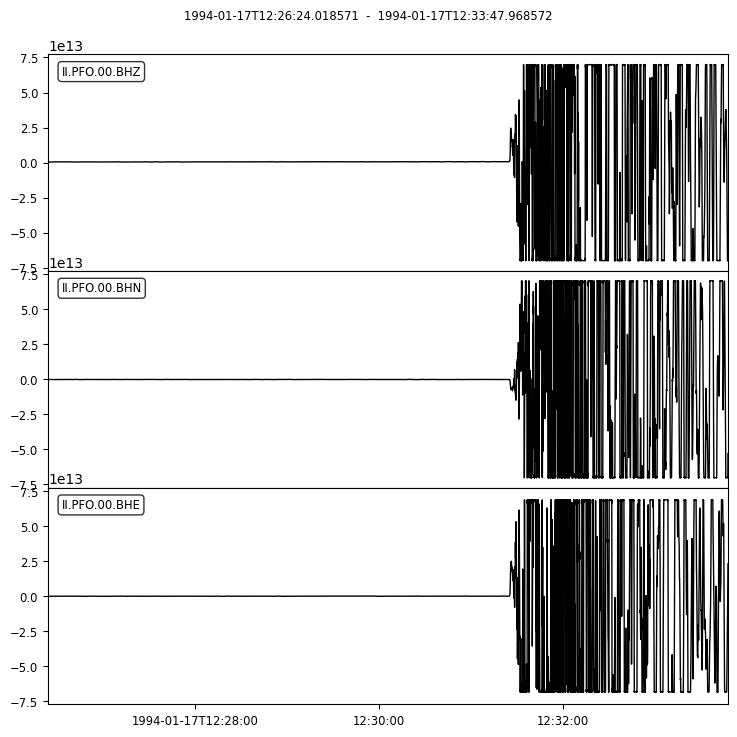

In [183]:
st = Stream(sta)
st.plot();

In [184]:
client = Client("IRIS")
starttime = st[0].stats.starttime
endtime = st[0].stats.endtime
inv = client.get_stations(network=net, station=name,
                          starttime=starttime, endtime=endtime,
                          level='response')

In [185]:
pre_filt = (0.01, 0.02, 8.0, 10.0)
for tr in st:
    tr.remove_response(inventory=inv, output="DISP", pre_filt=pre_filt,
                       plot=False, water_level=None)
# st.plot();

In [186]:
# # 26.8513° S	63.2373° W
# eq_lat = 18.820333
# eq_lon = -155.527167
# hdepth = 35.06  # depth in km

# # NOTE: balkan
# eq_lat = 42.425
# eq_lon = 16.2581
# hdepth = 10.0

# # NOTE: hawaii
# eq_lat = 18.820333
# eq_lon = -155.527167
# hdepth = 35.06

# NOTE: northridge
eq_lat = 34.136
eq_lon = -118.5826
hdepth = 15.9

In [187]:
velocity_model = TauPyModel(model='ak135')
vel_model_path = '../../data/AK135_lookup.csv'
lookup_table = pd.read_csv(vel_model_path)

alpha, beta = fn.extract_velocities(lookup_table, hdepth)
print(f'At depth {hdepth} km, P velocity = {alpha} km/s, S velocity = {beta} km/s')

At depth 15.9 km, P velocity = 5.8 km/s, S velocity = 3.46 km/s


In [188]:
print(f'Earthquake coordinates: lat {eq_lat}, lon {eq_lon}')
sta_lat = sta[0].stats.sac.stla
sta_lon = sta[0].stats.sac.stlo
print(f'Station coordinates: lat {sta_lat:.2f}, lon {sta_lon:.2f}')
event_locs = [eq_lat, eq_lon, sta_lat, sta_lon]
dist, az_check, baz_check = gps2dist_azimuth(*event_locs)
epdist = kilometers2degrees(dist/1000)
print(f'Distance between event and station: {dist/1000:.2f} km, {epdist:.2f} degrees')
print(f'Azimuth: {az_check:.2f}, Back-azimuth: {baz_check:.2f}')

az = st[0].stats.sac.az
baz = st[0].stats.sac.baz
print(f'Original azimuth: {az:.2f}, back-azimuth: {baz:.2f}')

Earthquake coordinates: lat 34.136, lon -118.5826
Station coordinates: lat 33.61, lon -116.46
Distance between event and station: 205.31 km, 1.85 degrees
Azimuth: 105.94, Back-azimuth: 287.13
Original azimuth: 105.94, back-azimuth: 287.12


In [189]:
p_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                        distance_in_degree=epdist, phase_list=['P'])
s_arrivals = velocity_model.get_travel_times(source_depth_in_km=hdepth,
                    distance_in_degree=epdist, phase_list=['S'])

# TODO in the loop that extracts data for me
if len(p_arrivals) > 0:
    p_arrival = p_arrivals[0]
    print(f'Predicted P arrival time: {p_arrival.time:.2f} s')
else:
    print('No P arrival predicted for this distance and depth.')

if len(s_arrivals) > 0:
    s_arrival = s_arrivals[0]
    print(f'Predicted S arrival time: {s_arrival.time:.2f} s')
else:
    print('No S arrival predicted for this distance and depth.')


# print out other travel times for information
# use the default phase list

p_inc = p_arrival.incident_angle
s_inc = s_arrival.incident_angle
print(f'Incidence angles: P = {p_inc:.2f}, S = {s_inc:.2f}')

Predicted P arrival time: 31.01 s
Predicted S arrival time: 54.02 s
Incidence angles: P = 45.84, S = 50.18


In [190]:
st._rotate_to_zne(inventory=inv)
# st.plot();

3 Trace(s) in Stream:
II.PFO.00.BHN | 1994-01-17T12:26:24.018571Z - 1994-01-17T12:33:47.968571Z | 20.0 Hz, 8880 samples
II.PFO.00.BHZ | 1994-01-17T12:26:24.018572Z - 1994-01-17T12:33:47.968572Z | 20.0 Hz, 8880 samples
II.PFO.00.BHE | 1994-01-17T12:26:24.018571Z - 1994-01-17T12:33:47.968571Z | 20.0 Hz, 8880 samples

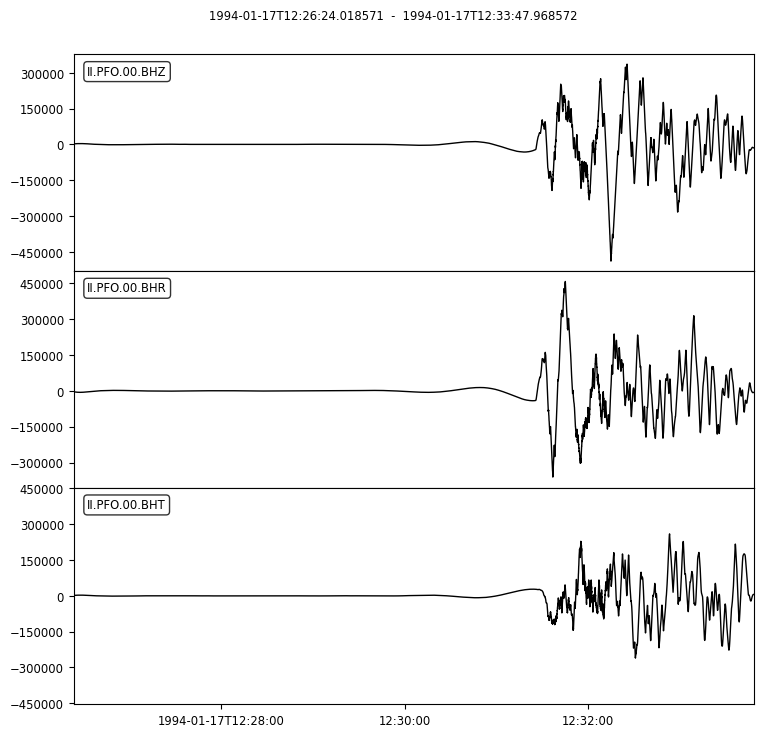

In [191]:
st_RT = st.copy()
st_RT.rotate('NE->RT', back_azimuth=baz)
st_RT.plot();

In [192]:
st_P = st.copy()
st_P.rotate('ZNE->LQT', back_azimuth=baz, inclination=p_inc)
st_S = st.copy()
st_S.rotate('ZNE->LQT', back_azimuth=baz, inclination=s_inc)

p_init, s_fin = st_P[0].stats.starttime, st_S[0].stats.endtime
p_arrival = p_init + 300  # 5 minutes after start
s_arrival = s_fin - 120  # 2 minutes before end

8880
8880
8880


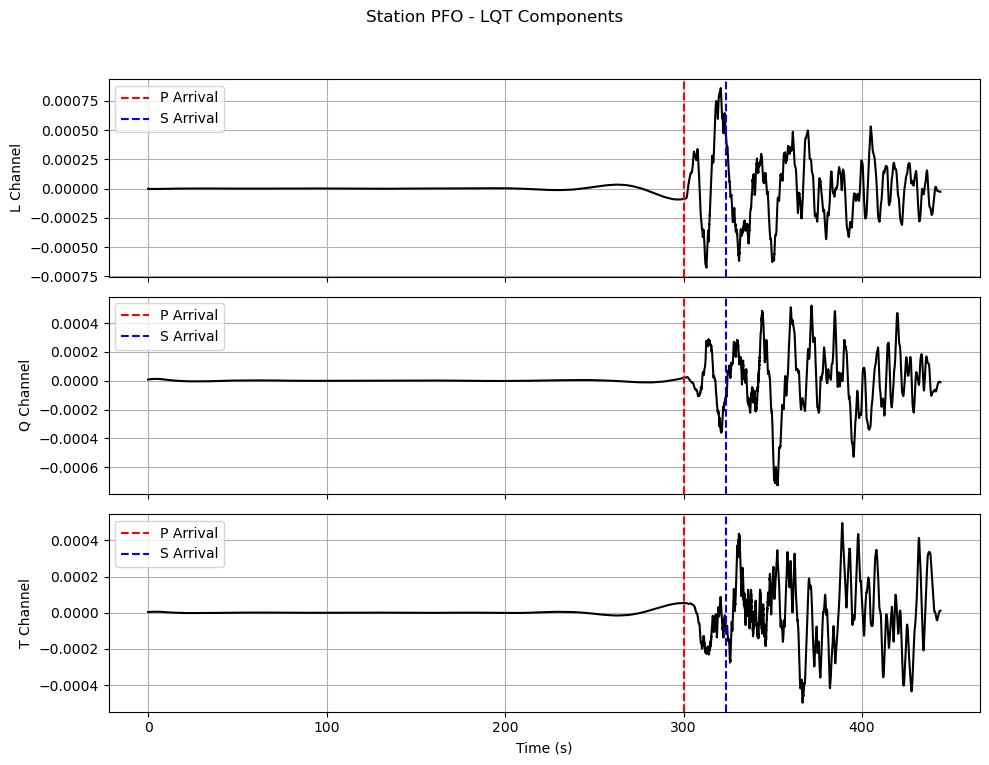

In [193]:
# make subplots of all three components L, Q, T
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 8), sharex=True)
components = ['L', 'Q', 'T']
for i, comp in enumerate(components):
    tr = st_P.select(component=comp)[0]
    print(len(tr.data))
    times = tr.times(type='relative')
    axes[i].plot(times, tr.data, 'k')
    axes[i].set_ylabel(f'{comp} Channel')
    axes[i].grid()
    axes[i].axvline(p_arrival-p_init, color='r', linestyle='--', label='P Arrival')
    axes[i].axvline(s_arrival-p_init, color='b', linestyle='--', label='S Arrival')
    axes[i].legend()

axes[-1].set_xlabel('Time (s)')
plt.suptitle(f'Station {name} - LQT Components')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [194]:
# TODO: ANALYSIS...
# if statement to check signal:noise ratio! now I get it
# QUESTION: how to calculate SNR? Look at the HASH paper

# window size... 5 seconds??? maybe

In [195]:
# overlayed plot of channels at p-arrival
tr_P = st_P.select(component='L')[0].copy()
tr_Sv = st_P.select(component='Q')[0].copy()
tr_Sv.data = -tr_Sv.data
tr_Sh = st_P.select(component='T')[0].copy()

p_start = p_arrival - 60 # 120
p_end = p_arrival + 60 # 80
tr_P = tr_P.slice(p_start, p_end)
tr_Sv = tr_Sv.slice(p_start, p_end)
tr_Sh = tr_Sh.slice(p_start, p_end)

In [196]:
# overlayed plot of channels at s-arrival
tr2_P = st_S.select(component='L')[0].copy()
tr2_Sv = st_S.select(component='Q')[0].copy()
tr2_Sv.data = -tr2_Sv.data
tr2_Sh = st_S.select(component='T')[0].copy()

s_arrival = tr2_Sv.stats.endtime - 120  # 2 minutes before end
s_start = s_arrival - 60
s_end = s_arrival + 60
tr2_P = tr2_P.slice(s_start, s_end)
tr2_Sv = tr2_Sv.slice(s_start, s_end)
tr2_Sh = tr2_Sh.slice(s_start, s_end)

In [197]:
# now gather the data as a 3D matrix
data = np.zeros((len(st), len(st[0].data)))
data.shape

# get the individual traces first
tr_ZL = st.select(component='Z')[0].copy()
tr_NQ = st.select(component='N')[0].copy()
tr_ET = st.select(component='E')[0].copy()

# then preprocess them
for tr in [tr_ZL, tr_NQ, tr_ET]:
    tr.detrend('linear')
    tr.detrend('demean')
    tr.filter('lowpass', freq=.1,
              corners=4, zerophase=False)

# then fill the data matrix
data[0, :] = tr_ZL.data
data[1, :] = tr_NQ.data
data[2, :] = tr_ET.data

# get azimuth, p and s incidence angles
my_az = (baz - 180) % 360
my_p_inc = p_inc
my_s_inc = s_inc

# matrix rotation ZNE -> ZRT
importlib.reload(fn)
R_zne2zrt = fn.zne2zrt_matrix(baz, deg=True)
R_zrt2lqt = fn.zrt2lqt_matrix(p_inc=my_p_inc, s_inc=my_s_inc, deg=True)
data_zrt = R_zne2zrt @ data
data_lqt = R_zrt2lqt @ data_zrt

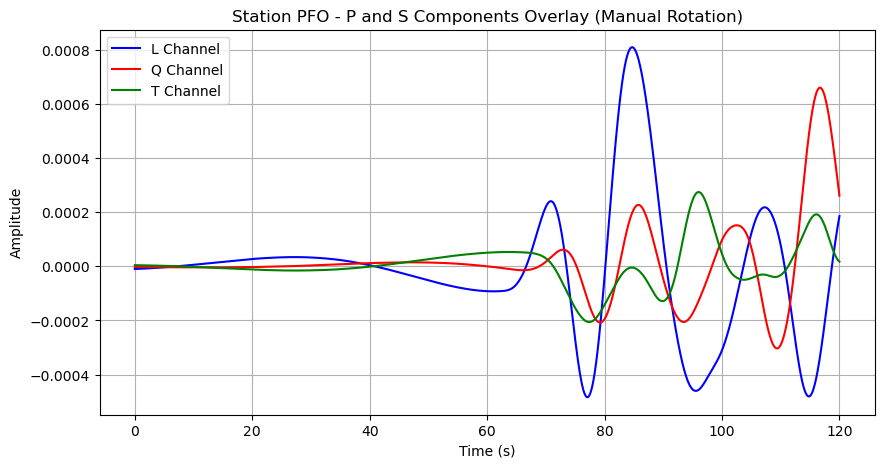

In [198]:
# using p_start and p_end to slice the data_lqt matrix
# use p init, sampling rate and delta to get indices
delta = st[0].stats.delta

# use p_init as starting time
p_start_idx = int((p_start - p_init) / delta)
p_end_idx = int((p_end - p_init) / delta)
sliced_data_p = data_lqt[:, p_start_idx:p_end_idx+1]

# overlayed plot of channels at p-arrival
fig, ax = plt.subplots(figsize=(10, 5))
sliced_times_p = np.arange(sliced_data_p.shape[1]) * delta # + (p_start - p_init)
ax.plot(sliced_times_p, sliced_data_p[0, :], 'b', label='L Channel')
ax.plot(sliced_times_p, sliced_data_p[1, :], 'r', label='Q Channel')
ax.plot(sliced_times_p, sliced_data_p[2, :], 'g', label='T Channel')


# ax.axvspan(105, 125, alpha=0.3, color='yellow', label='Zerophase off')

ax.set_xlabel('Time (s)')
ax.set_ylabel('Amplitude')
ax.set_title(f'Station {name} - P and S Components Overlay (Manual Rotation)')
ax.legend()
ax.grid()
plt.show()

In [199]:
import numpy as np
def aic(data):
    """
    Compute the AIC picker around a given time window.

    Parameters
    ----------
    arr : np.ndarray
        The input array for which to compute AIC values.

    Returns
    -------
    np.ndarray
        An array of AIC values.
    """
    N = len(data)
    epsilon = 1e-10

    aic_values = []
    for k in range(1, N):
        first_segment = data[:k]
        second_segment = data[k:]

        # Avoid log(0) by thresholding small variances
        var_first = max(np.var(first_segment), epsilon)
        var_second = max(np.var(second_segment), epsilon)

        # Compute the AIC function
        aic = k * np.log(var_first) + (N - k) * np.log(var_second)
        aic_values.append(aic)
    
    return np.array(aic_values)

data = [1,2,3,4,5]
aic(data)

array([-22.1333,  -3.989 ,  -3.989 , -22.1333])

2400 2401


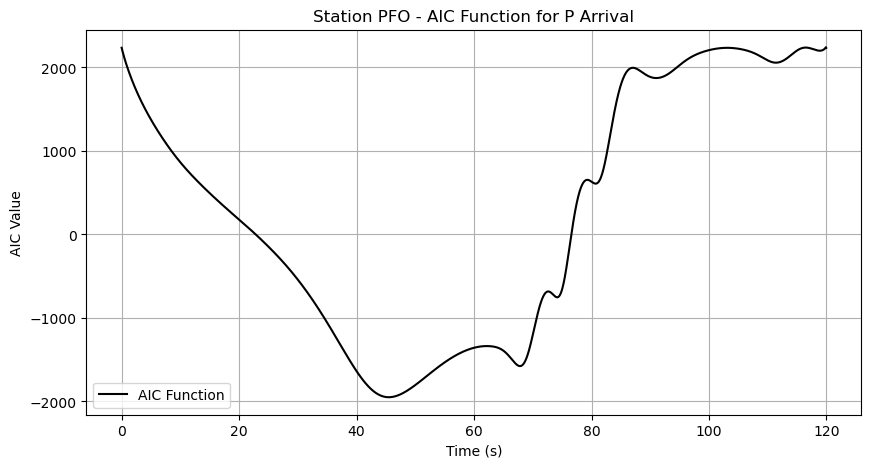

In [200]:
scale = 1/np.mean(np.abs(sliced_data_p[0, :]))
output = aic(scale*sliced_data_p[0, :])
print(len(output), len(sliced_data_p[0, :]))

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sliced_times_p[:-1], output, 'k', label='AIC Function')
ax.set_xlabel('Time (s)')
ax.set_ylabel('AIC Value')
ax.set_title(f'Station {name} - AIC Function for P Arrival')
ax.legend()
ax.grid()
plt.show()

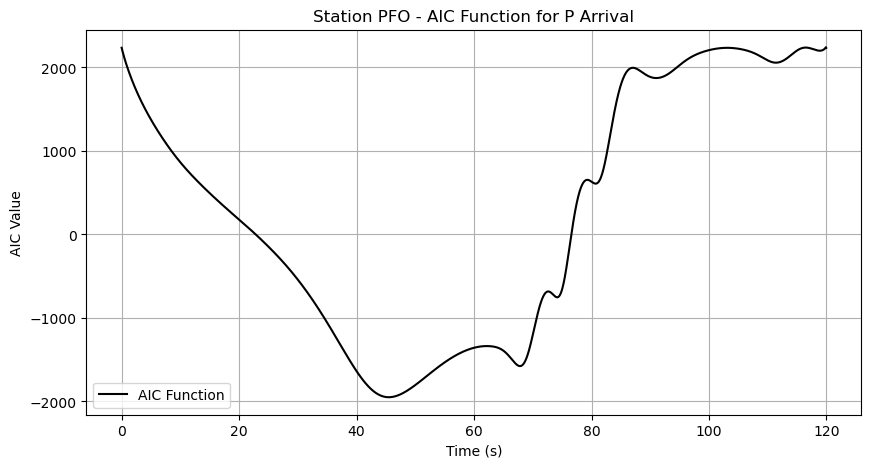

-1.0

In [201]:
p_pol, new_output = get_p_polarity(stream=Stream(sta),
                            p_inc=p_inc, return_aic=True)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(sliced_times_p[:-1], new_output, 'k', label='AIC Function')
ax.set_xlabel('Time (s)')
ax.set_ylabel('AIC Value')
ax.set_title(f'Station {name} - AIC Function for P Arrival')
ax.legend()
ax.grid()
plt.show()
p_pol

In [202]:
p_pol

-1.0

In [203]:
# interest = np.argmin(output)
# final_zoom = sliced_data_p[0, interest:interest+6]
# diffs = scale * np.diff(final_zoom)
# signs = np.sign(diffs)

# # polarity is the most common sign in the first 5 [chosen]
# # differences after the minimum AIC value
# polarity = np.sign(np.sum(signs))
# polarity

# # polarity is the sign of the first turning point after the minimum AIC value

In [204]:
# # check output vs new_output
# sum(output - new_output)

In [205]:
# NOW I CAN FINALLY BUILD THE DATAFRAME FOR POLARITIES!
# FIRST, WRAP THE PROCESS FOR ONE STATION IN A FUNCTION, THEN LOOP OVER ALL STATIONS